# Tutorial 10 — Calibration and energy use

## 1. Problem / context

Daily energy use (kWh) is plotted against CPU load (%). We want a fitted line, a reading of the slope in kWh per percentage point, residual checks, and a prediction for a new day at 70% load. A second example is warehouse CPU versus order lines (`cpu_order_lines.xlsx`).

Statsmodels is the inference tool. Scikit-learn is used only to fit a prediction model and to illustrate a train/test split — it does not produce $t$-tests or confidence intervals for $\beta_1$.

## 2. Core theory

$$
Y=\beta_0+\beta_1 x+\varepsilon,
\qquad
\hat y=\hat\beta_0+\hat\beta_1 x.
$$

Least squares minimises $\sum(y_i-\hat y_i)^2$. $R^2$ is the fraction of variance in $y$ associated with the line; it is not causation.

A **confidence interval** for the mean response at $x_0$ is narrower than a **prediction interval** for a new observation at $x_0$.

Residual plots should look patternless. A QQ-plot of residuals checks the normal-error approximation used for inference.

Detailed algebraic forms are in [Calculating_metrics.md](Calculating_metrics.md).

## 3. From mathematics to Python

| Task | Tool |
| --- | --- |
| Inference, CI, residual diagnostics | `statsmodels.api.OLS` |
| Prediction API, train/test | `sklearn.linear_model.LinearRegression` |

## 4. Python implementation


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

candidates = [Path("data"), Path("../data")]
DATA = next(p for p in candidates if p.exists())
df = pd.read_csv(DATA / "energy_load.csv")
x = df["cpu_load_pct"]
y = df["energy_kwh"]


Matplotlib is building the font cache; this may take a moment.


In [2]:
X = sm.add_constant(x)
ols = sm.OLS(y, X).fit()
print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:             energy_kwh   R-squared:                       0.847
Model:                            OLS   Adj. R-squared:                  0.842
Method:                 Least Squares   F-statistic:                     209.6
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           4.77e-17
Time:                        12:48:32   Log-Likelihood:                -112.62
No. Observations:                  40   AIC:                             229.2
Df Residuals:                      38   BIC:                             232.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           10.1340      1.668      6.074   

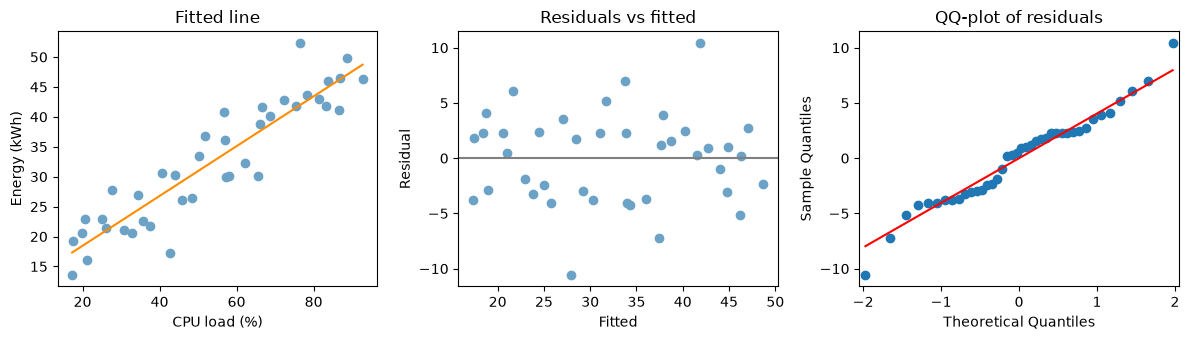

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].scatter(x, y, color="#6CA2C6")
xx = np.linspace(x.min(), x.max(), 50)
axes[0].plot(xx, ols.predict(sm.add_constant(xx)), color="#FF8C00")
axes[0].set_xlabel("CPU load (%)")
axes[0].set_ylabel("Energy (kWh)")
axes[0].set_title("Fitted line")

fitted = ols.fittedvalues
resid = ols.resid
axes[1].scatter(fitted, resid, color="#6CA2C6")
axes[1].axhline(0, color="grey")
axes[1].set_xlabel("Fitted")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs fitted")

sm.qqplot(resid, line="s", ax=axes[2])
axes[2].set_title("QQ-plot of residuals")
plt.tight_layout()
plt.show()


Prediction at 70% load:


In [4]:
pred = ols.get_prediction([1, 70])
print(pred.summary_frame(alpha=0.05))


        mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0  39.263607  0.811388      37.621038      40.906177     30.710172   

   obs_ci_upper  
0     47.817043  


scikit-learn as a prediction tool, not as inference:


In [5]:
X_sk = x.to_numpy().reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(
    X_sk, y, test_size=0.25, random_state=42
)
lin = LinearRegression().fit(X_train, y_train)
print("sklearn intercept, slope:", lin.intercept_, lin.coef_[0])
print("test R^2:", lin.score(X_test, y_test))
print("sklearn does not give SE(beta1) or a p-value; use statsmodels for that.")


sklearn intercept, slope: 11.322925228329687 0.4065298628041835
test R^2: 0.773309105798884
sklearn does not give SE(beta1) or a p-value; use statsmodels for that.


In [6]:
cpu = pd.read_excel(DATA / "cpu_order_lines.xlsx")
print(sm.OLS(cpu["CPU_utilisation"], sm.add_constant(cpu["Order_lines_per_day"])).fit().params)


const                  4.629117
Order_lines_per_day    0.001945
dtype: float64


## 5. Interpretation

If $\hat\beta_1\approx 0.38$, each extra percentage point of CPU load is associated with about 0.38 kWh extra energy **in this linear model**. That is not a licence to claim that load **causes** energy without a design that supports causation. The prediction interval at 70% is the honest range for a **new day**, not the interval for the mean of all days at 70%.

## 6. Common mistakes / things to notice

- Using scikit-learn alone and then quoting a $p$-value that does not exist there.
- Treating $R^2=0.8$ as “the model is true”.
- Extrapolating far outside the observed load range.

## 7. Short worked example

Compare `ols.params["cpu_load_pct"]` with `lin.coef_[0]` on the **full** data; they should match least squares. They need not match the train/test sklearn fit, because that fit used a subset.

**Conclusion in one sentence:** Fit and interpret the energy–load line with statsmodels so that slope, $R^2$, residual plots, and prediction intervals are available; use scikit-learn only as a prediction API, not as a substitute for statistical inference.
